# Hair-removal pipeline

1. **DullRazor variants** — kernel, blur, dilation, threshold.
2. **The problem** — plain black-hat false-flags dark, hairless lesions.
3. **The fix** — `hair_mask`: keep only long, thin components -> no false hair.
4. **Whole pipeline** — DullRazor every image, record `hair_frac` in the same pass.
5. **Outlier handling** — post-hoc, from the recorded table: Tukey fences on
   `log(hair_frac)`; flagged images are reverted to the raw file in place.
6. **Outlier summary** — counts, `hair_frac` ranges, class balance.

## Setup

In [1]:
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
BASE      = '/content/drive/MyDrive/Melanoma Project'
TRAIN_DIR = BASE + "/train"
TEST_DIR  = BASE + "/test"

train_df = pd.read_csv(BASE + '/train_labels.csv')
test_df  = pd.read_csv(BASE + '/test_labels.csv')
print(train_df.shape, test_df.shape)

(6864, 8) (1988, 8)


In [4]:
def add_image_path(df, img_dir, ext=".jpg"):
    df = df.copy()
    df["image_path"] = df["image_name"].apply(lambda n: img_dir + f"/{n}{ext}")
    return df

train_df = add_image_path(train_df, TRAIN_DIR)
test_df  = add_image_path(test_df,  TEST_DIR)

def to_rgb(path):
    '''Read an image as an RGB uint8 array (H, W, 3).'''
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

train_df[["image_name", "target", "image_path"]].head()

,image_name,target,image_path
0,ISIC_0015719,0,/content/drive/MyDrive/Melanoma Project/train/...
1,ISIC_0074542,0,/content/drive/MyDrive/Melanoma Project/train/...
2,ISIC_0076545,0,/content/drive/MyDrive/Melanoma Project/train/...
3,ISIC_0082348,0,/content/drive/MyDrive/Melanoma Project/train/...
4,ISIC_0085172,0,/content/drive/MyDrive/Melanoma Project/train/...


## 1. DullRazor variants

All four: grayscale -> black-hat -> threshold -> `cv2.inpaint`

Comparison
| | kernel | blur on black-hat | threshold | mask dilation |
|---|---|---|---|---|
| **a** | **cross 17** | 3x3 | 10 | none |
| **b** | ellipse 17 | none | 10 | 3 px |
| **c** | ellipse 17 | 3x3 | 10 | 3 px |
| **d** | ellipse 17 | none | **8** | 3 px |

In [5]:
RS = 3   # fixed sample for every method comparison

def preview(fn, n=3, rs=RS, tag=""):
    for name in train_df.sample(n, random_state=rs)["image_name"]:
        path = train_df.loc[train_df["image_name"] == name, "image_path"].iloc[0]
        rgb = to_rgb(path)
        clean, mask = fn(rgb)
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(rgb);               ax[0].set_title(f"{tag}  {name} - raw")
        ax[1].imshow(mask, cmap="gray"); ax[1].set_title("hair mask")
        ax[2].imshow(clean);             ax[2].set_title("hair removed")
        for a in ax:
            a.axis("off")
        plt.tight_layout(); plt.show()

### a  —  cross kernel + Gaussian blur, no dilation  (preserves texture, leaves faint diagonal hair)

In [6]:
def dullrazor(rgb, kernel_size=17, thresh=10, inpaint_radius=1):
    '''Faithful DullRazor (Parsaniya / Lee et al.). Returns (clean_rgb, hair_mask).'''
    gray     = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    kernel   = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blackhat = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
    _, mask  = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)
    clean    = cv2.inpaint(rgb, mask, inpaint_radius, cv2.INPAINT_TELEA)
    return clean, mask

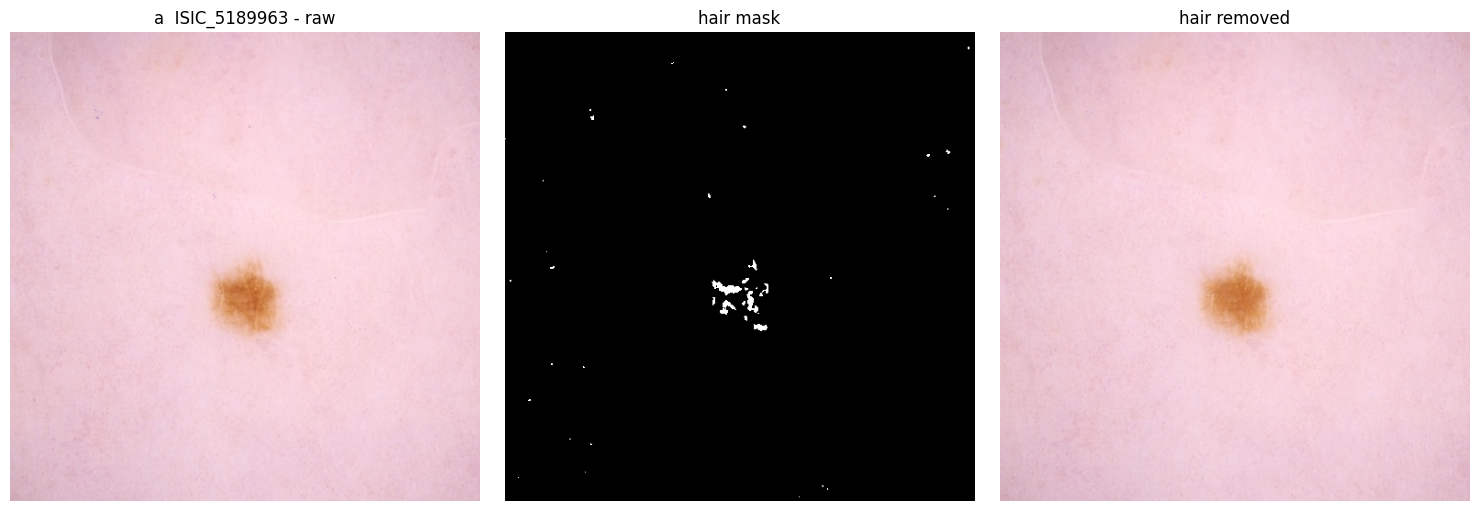

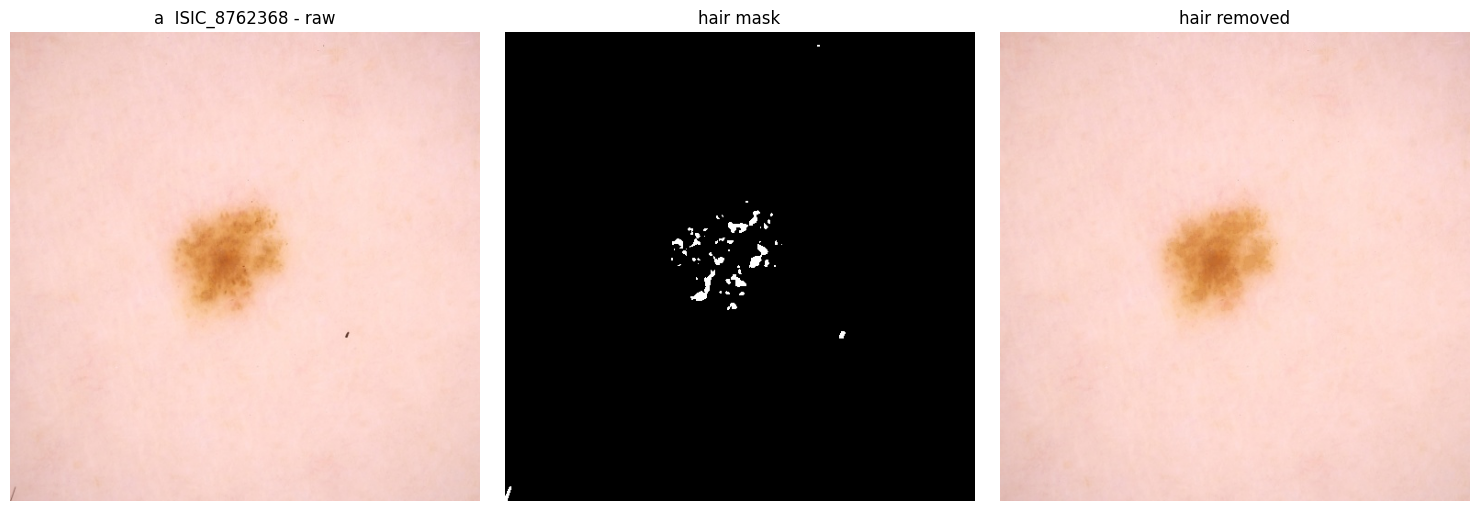

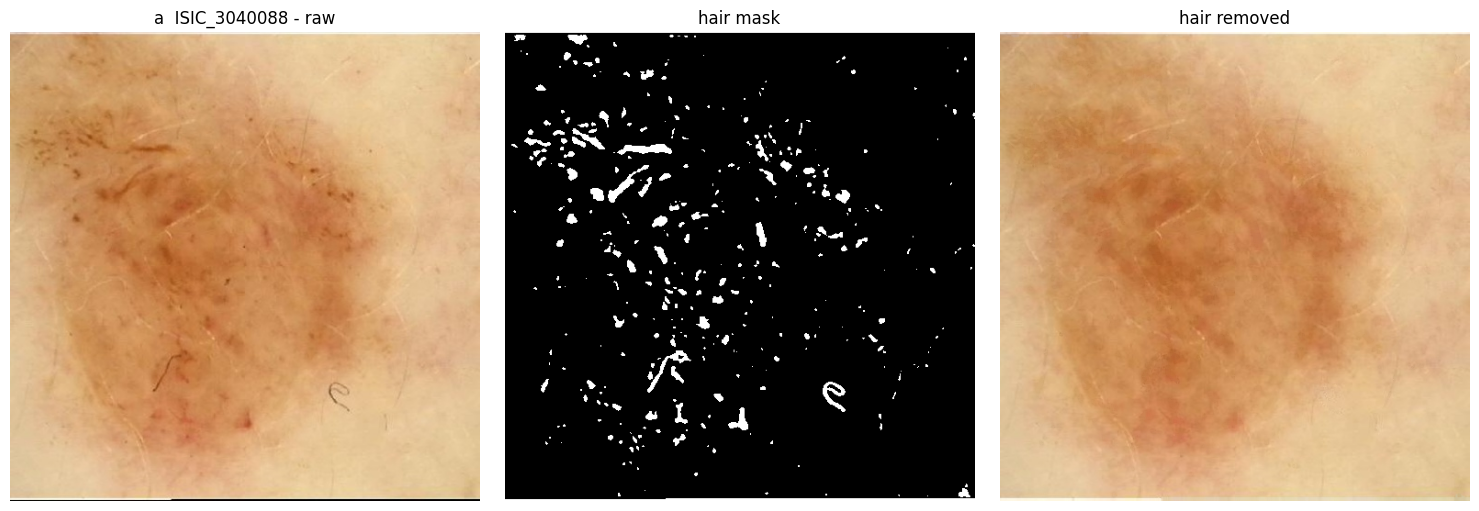

In [7]:
preview(dullrazor, tag='a')

### b  —  ellipse kernel + mask dilation, no blur  (removes all hair, slightly softer)

In [8]:
def remove_hair(rgb, kernel_size=17, thresh=10, inpaint_radius=1):
    gray     = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask  = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)
    mask     = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    clean    = cv2.inpaint(rgb, mask, inpaint_radius, cv2.INPAINT_TELEA)
    return clean, mask

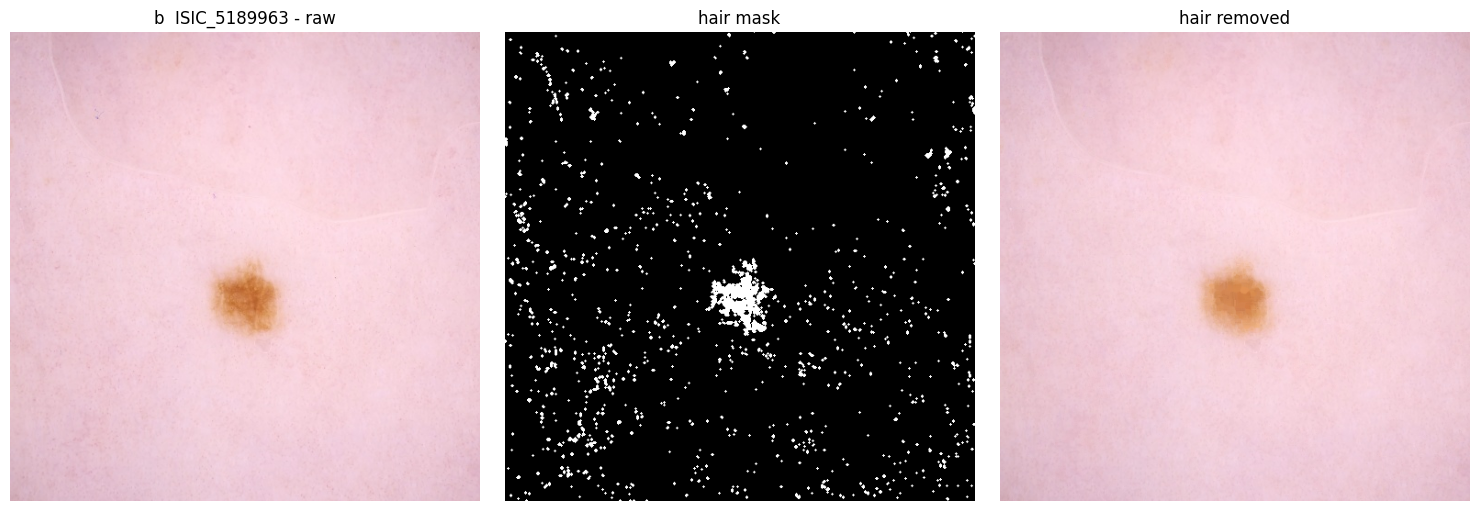

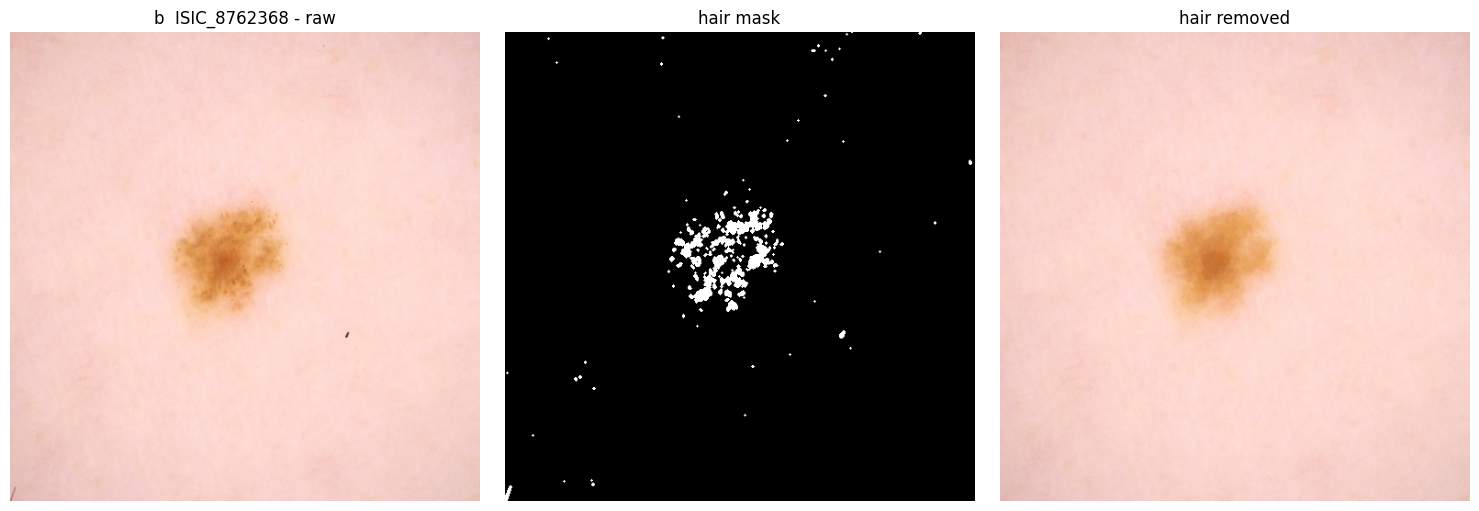

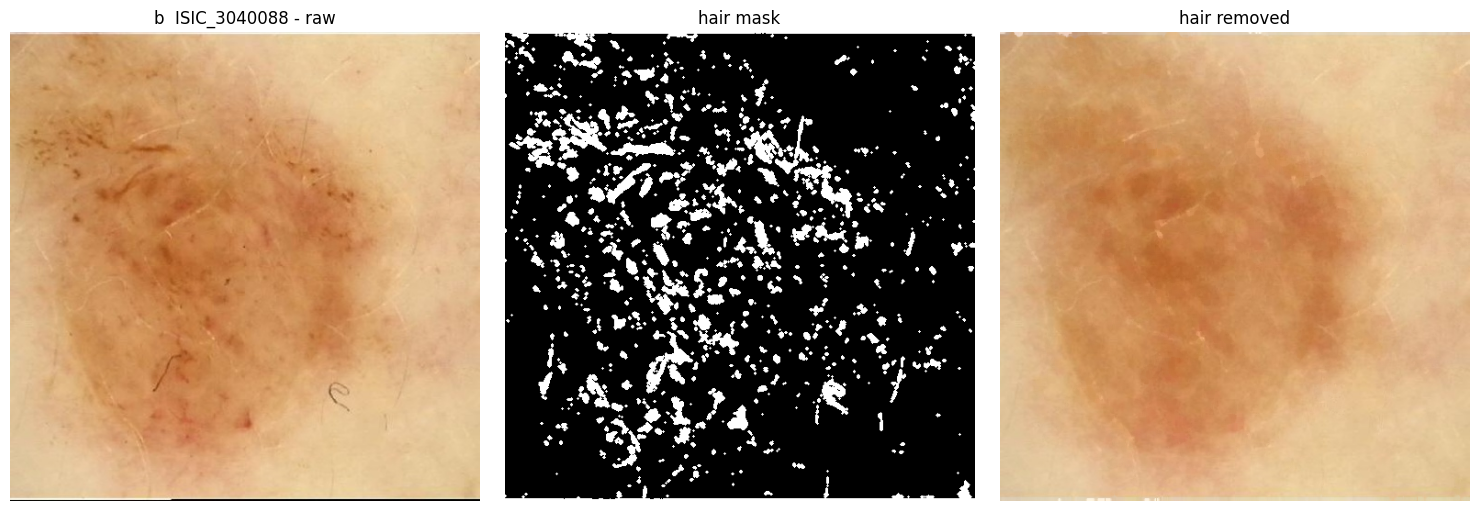

In [9]:
preview(remove_hair, tag='b')

### c  —  ellipse + blur + dilation  (cleanest mask + full edge coverage)

In [10]:
def dullrazor_blur_dilate(rgb, kernel_size=17, thresh=10, inpaint_radius=1,
                          use_blur=True, dilate_size=3):
    gray     = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    if use_blur:
        blackhat = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
    _, mask  = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)
    if dilate_size:
        mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_size, dilate_size)))
    clean = cv2.inpaint(rgb, mask, inpaint_radius, cv2.INPAINT_TELEA)
    return clean, mask

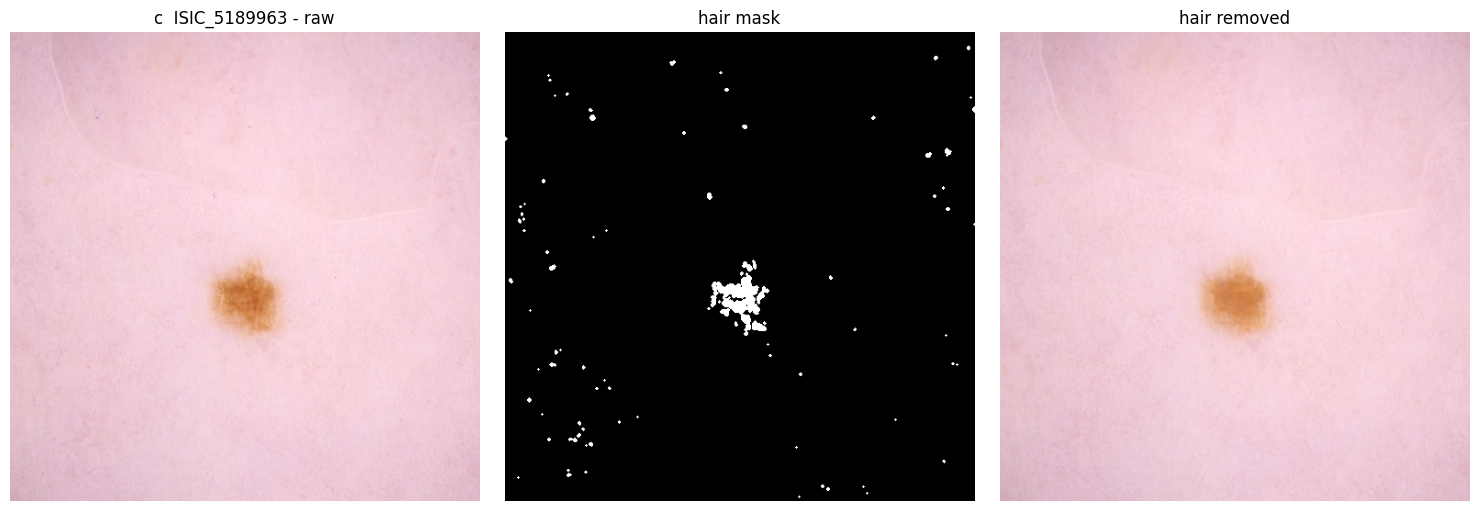

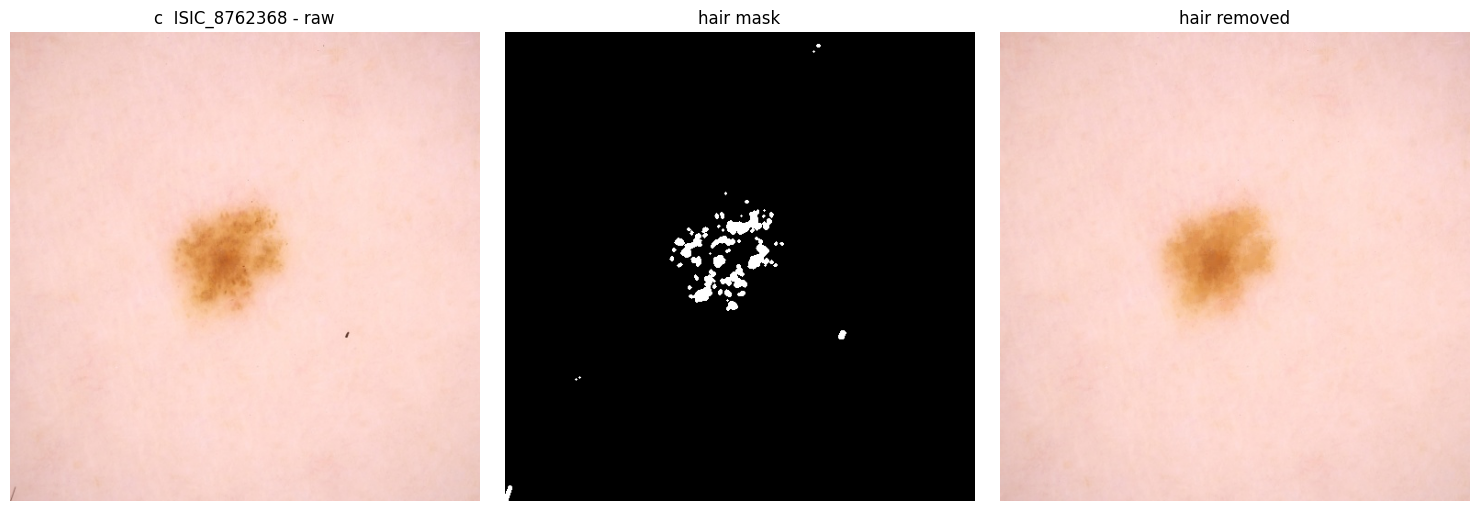

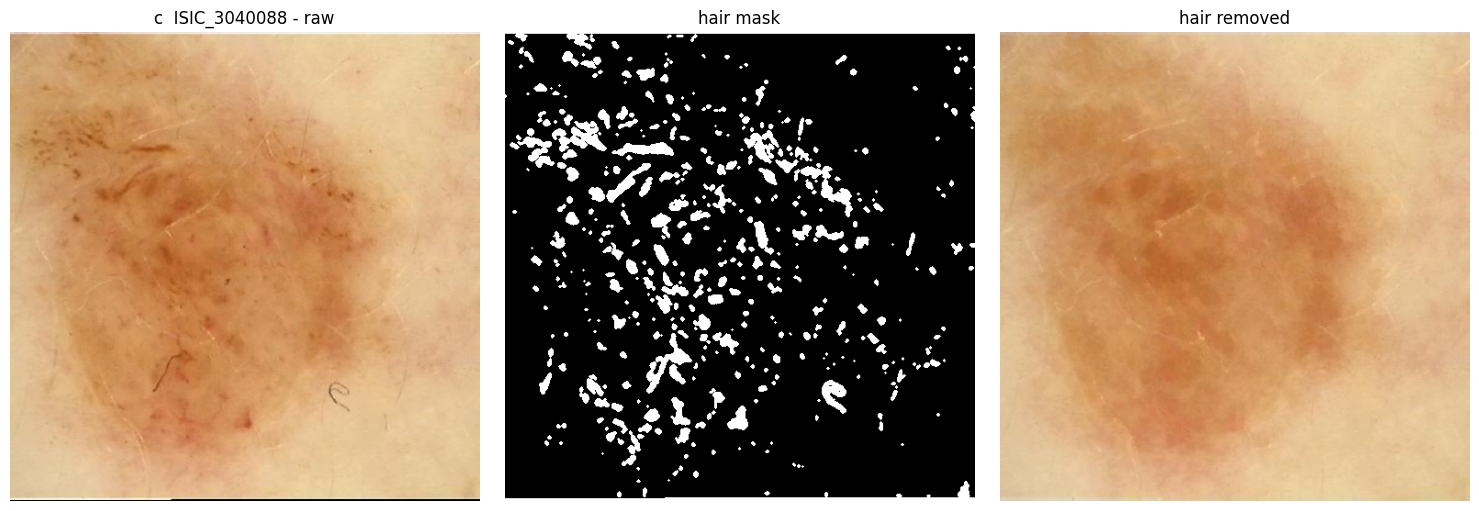

In [11]:
preview(dullrazor_blur_dilate, tag='c')

### d  —  ellipse, threshold 8, dilation  (most sensitive to faint hair; a bit more speckle)

In [12]:
def dullrazor_sensitive(rgb, kernel_size=17, thresh=8, inpaint_radius=1, dilate_size=3):
    '''Lower threshold + no blur -> keeps the weak black-hat peaks of faint hair.'''
    gray     = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask  = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)
    if dilate_size:
        mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_size, dilate_size)))
    clean = cv2.inpaint(rgb, mask, inpaint_radius, cv2.INPAINT_TELEA)
    return clean, mask

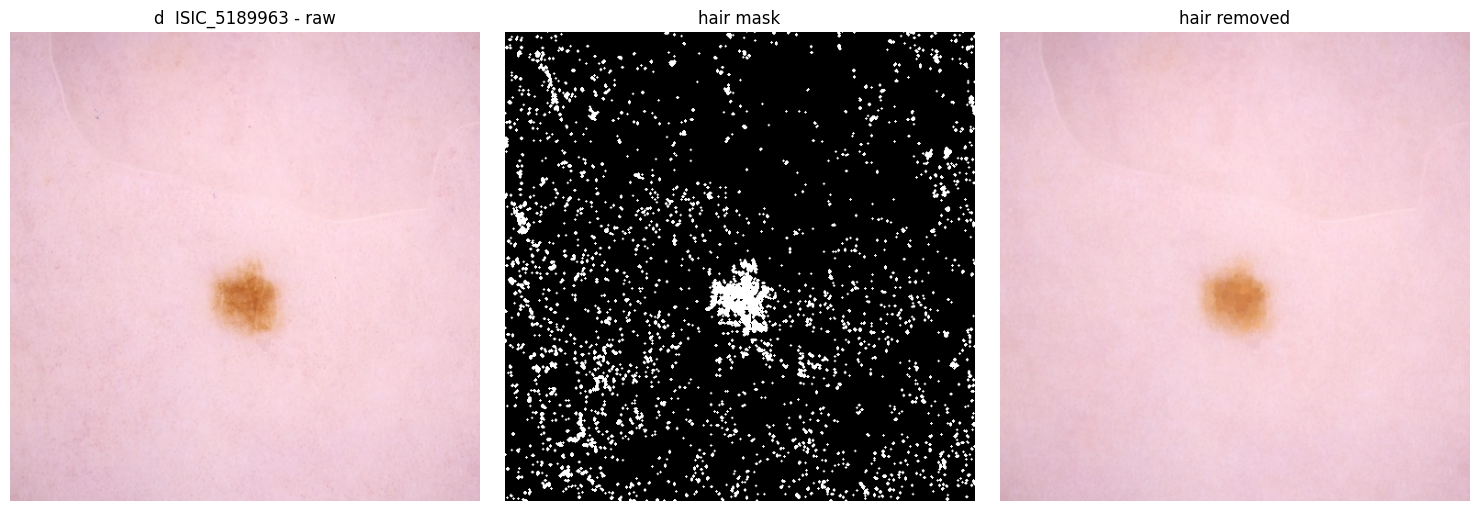

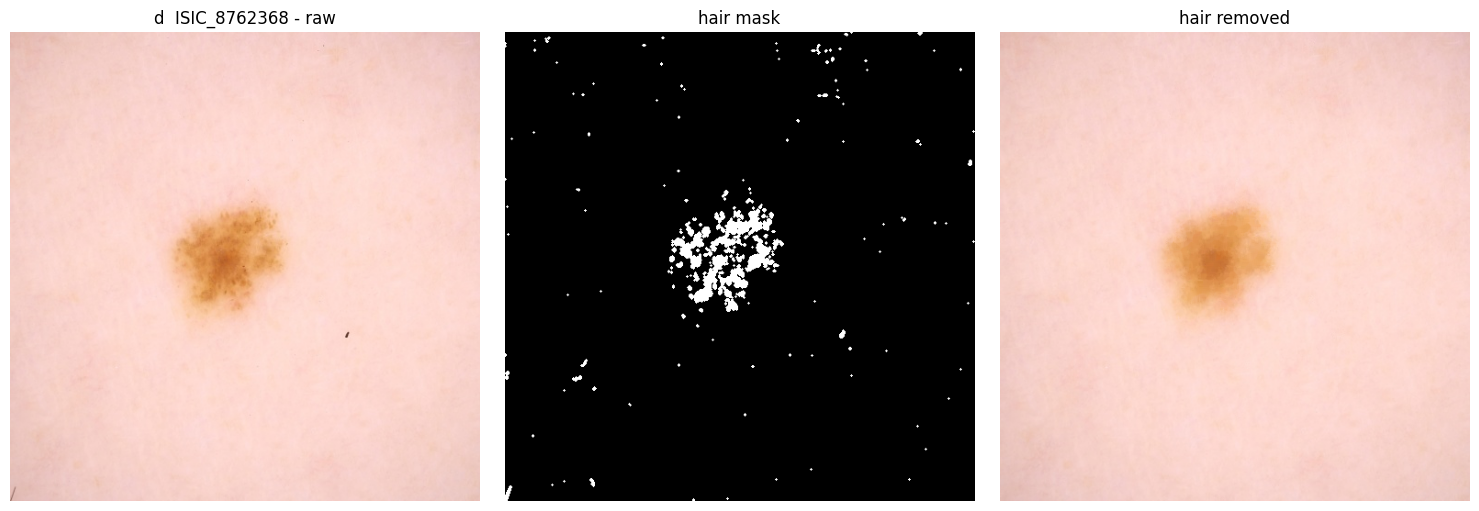

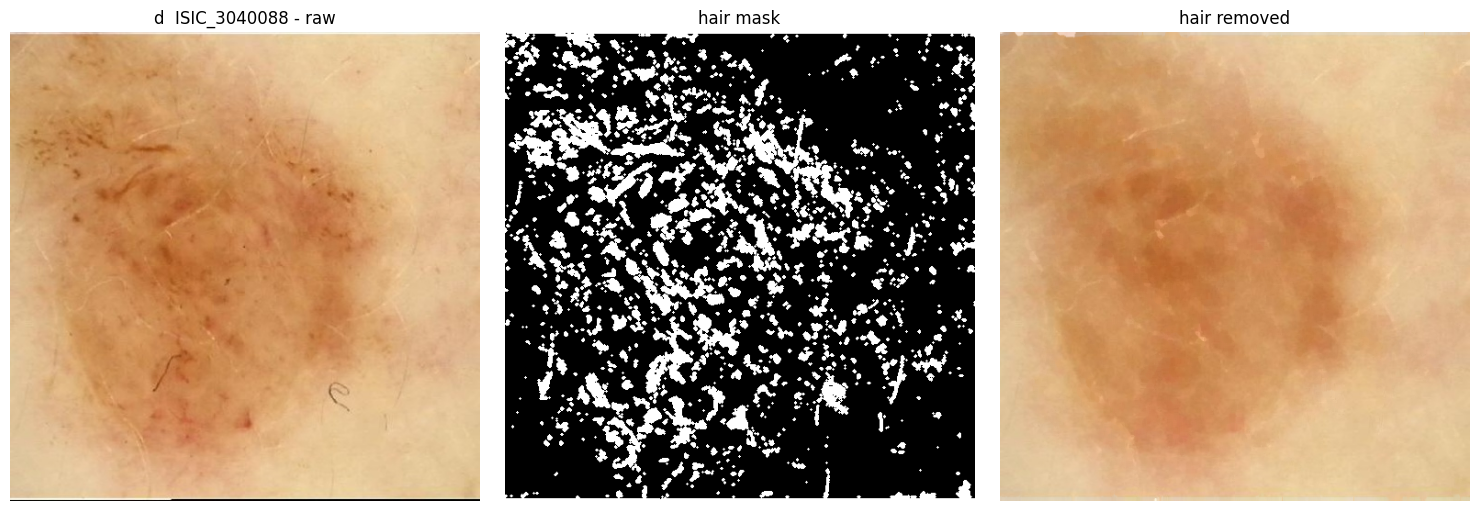

In [ ]:

preview(dullrazor_sensitive, tag='d')

## 2. The problem: black-hat false-flags dark, hairless lesions

Black-hat marks **any thin dark structure**. A pigmented lesion is full of them:
the pigment network (thin dark mesh), dots / globules, and the lesion border.
On `sample(3, random_state=0)` there is little or no hair, yet a plain black-hat +
threshold mask lights up on the lesion -- so `hair_frac` would be wrongly high and
the image would be sent through DullRazor for nothing.

ISIC_5189963: naive mask flags 1.38% of the image (little/no real hair)


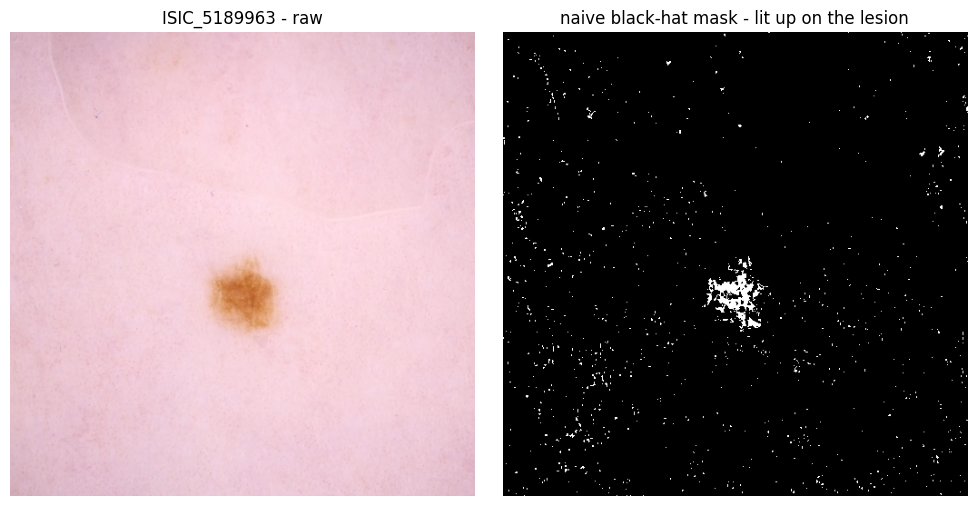

ISIC_8762368: naive mask flags 0.95% of the image (little/no real hair)


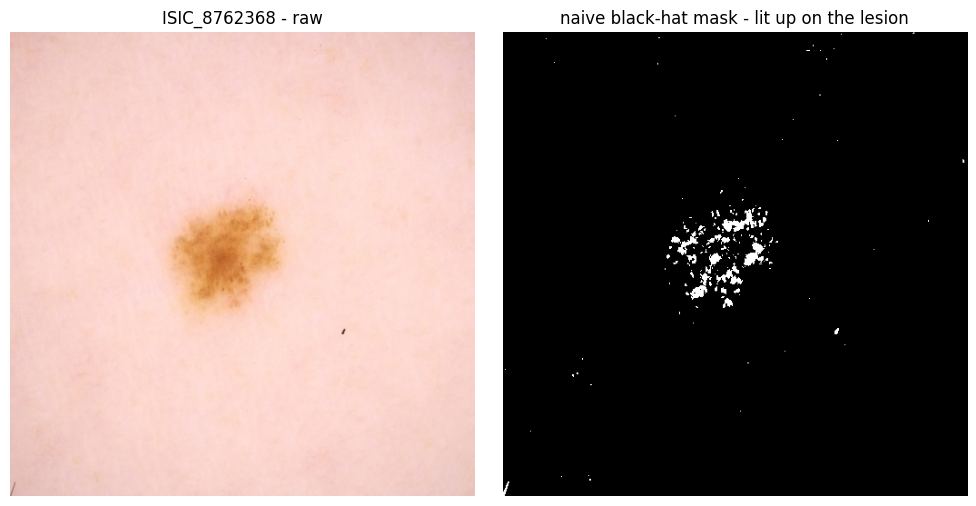

ISIC_3040088: naive mask flags 7.87% of the image (little/no real hair)


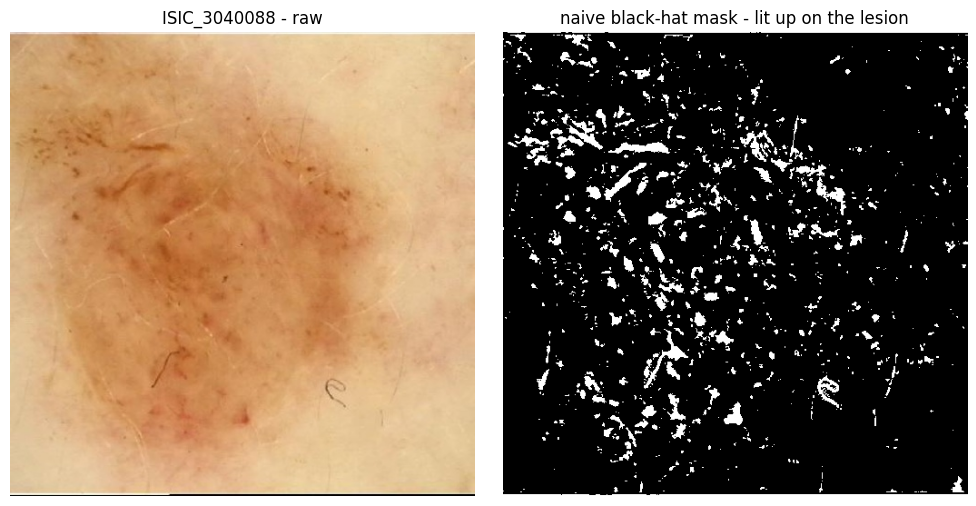

In [14]:
def naive_mask(rgb, kernel_size=17, thresh=10):
    '''Plain black-hat + threshold. No shape filter -> flags network / dots / rim.'''
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    bh   = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, k)
    _, m = cv2.threshold(bh, thresh, 255, cv2.THRESH_BINARY)
    return m

EXAMPLES = list(train_df.sample(3, random_state=3)["image_name"])
for name in EXAMPLES:
    path = train_df.loc[train_df["image_name"] == name, "image_path"].iloc[0]
    rgb  = to_rgb(path)
    nm   = naive_mask(rgb)
    print(f"{name}: naive mask flags {100 * (nm > 0).mean():.2f}% of the image (little/no real hair)")
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(rgb);            ax[0].set_title(f"{name} - raw")
    ax[1].imshow(nm, cmap="gray"); ax[1].set_title("naive black-hat mask - lit up on the lesion")
    for a in ax:
        a.axis("off")
    plt.tight_layout(); plt.show()

## 3. The fix: shape-filtered `hair_mask`

After thresholding, judge each connected blob by its **minimum-area rectangle**
and keep only ones shaped like a strand:

- **long**   -- longer side >= `min_len` (rejects short pigment-network segments)
- **narrow** -- long / short side >= `min_aspect` (rejects round dots & globules,
  and the roughly-square blob a connected network mesh forms)
- **filled** -- blob fills >= `min_fill` of that rectangle (rejects the poorly-
  filled arc a lesion border makes)

It tests a **ratio** (long vs short), not an absolute width, so a **thick** hair
passes as long as it is still much longer than it is wide. The black-hat kernel
is widened to 25 px so thick hairs register solidly in the first place.

In [15]:
def hair_mask(rgb, kernel_size=25, thresh=12,
              min_len=45, min_aspect=3.0, min_fill=0.30, min_area=30):
    '''Black-hat -> threshold -> keep components whose minimum-area rectangle is
    long, narrow and reasonably filled -- a strand of ANY thickness. Rejects
    short segments (network), round blobs (dots / globules) and poorly-filled
    arcs (lesion rim).'''
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    bh   = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, k)
    _, raw = cv2.threshold(bh, thresh, 255, cv2.THRESH_BINARY)
    raw = cv2.morphologyEx(raw, cv2.MORPH_CLOSE,
                           cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))   # bridge tiny gaps

    n, lab, st, _ = cv2.connectedComponentsWithStats(raw, 8)
    keep = np.zeros(raw.shape, np.uint8)
    for i in range(1, n):
        area = int(st[i, cv2.CC_STAT_AREA])
        if area < min_area:                                     # skip specks (cheap, before np.where)
            continue
        ys, xs = np.where(lab == i)
        (rw, rh) = cv2.minAreaRect(np.column_stack([xs, ys]).astype(np.int32))[1]
        long_side  = max(rw, rh)
        short_side = max(min(rw, rh), 1.0)
        aspect = long_side / short_side                         # elongation, rotation-invariant
        fill   = area / (long_side * short_side)                # how line-like (vs curved arc)
        if long_side >= min_len and aspect >= min_aspect and fill >= min_fill:
            keep[lab == i] = 255
    return keep


def hair_frac(rgb, **kw):
    '''Routing / outlier score: fraction of the image inside hair_mask.'''
    return float((hair_mask(rgb, **kw) > 0).mean())



### Same `random_state=3` examples, now with `hair_frac` -- the false positives are gone

ISIC_5189963: naive   1.38%   ->   hair_frac 0.000%


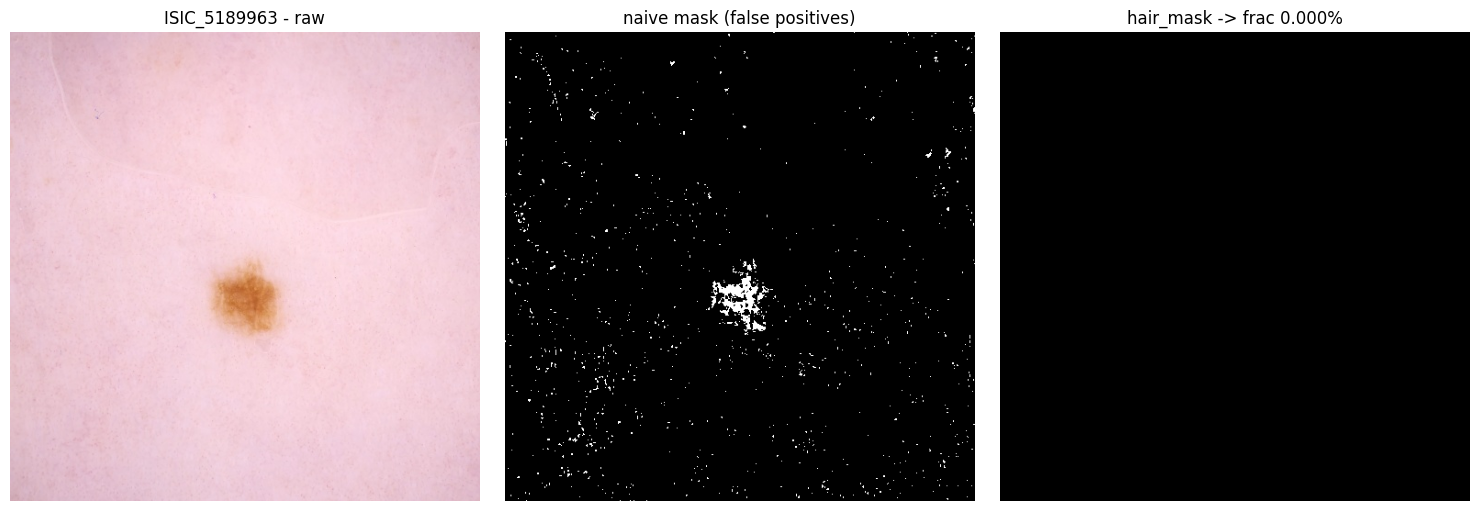

ISIC_8762368: naive   0.95%   ->   hair_frac 0.000%


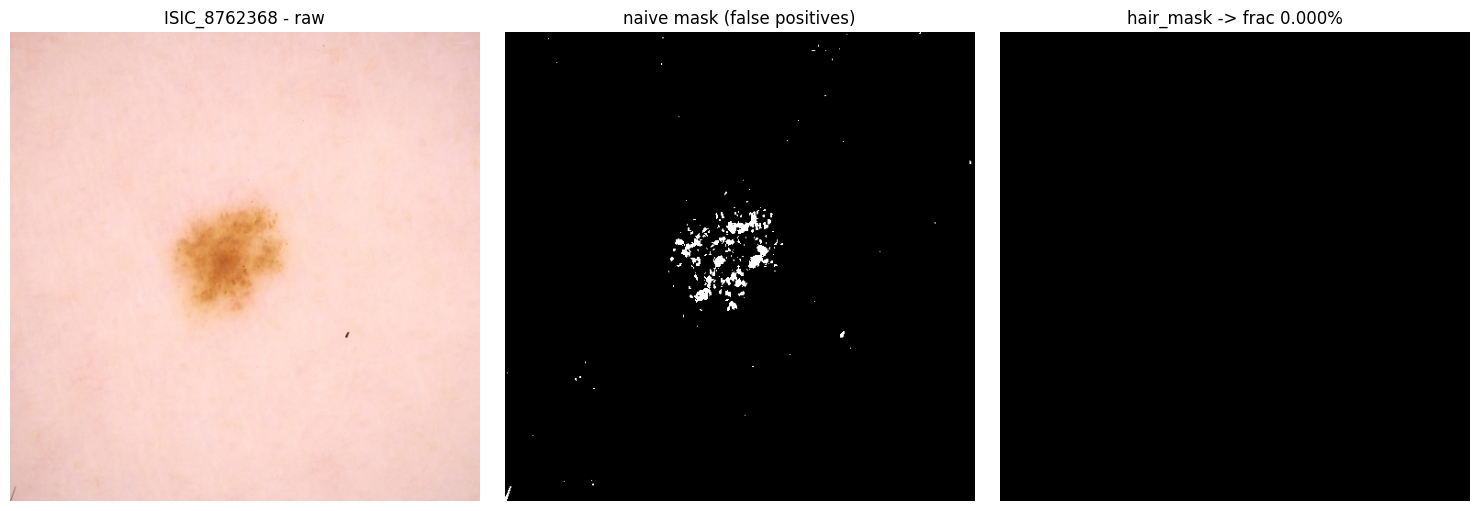

ISIC_3040088: naive   7.87%   ->   hair_frac 0.252%


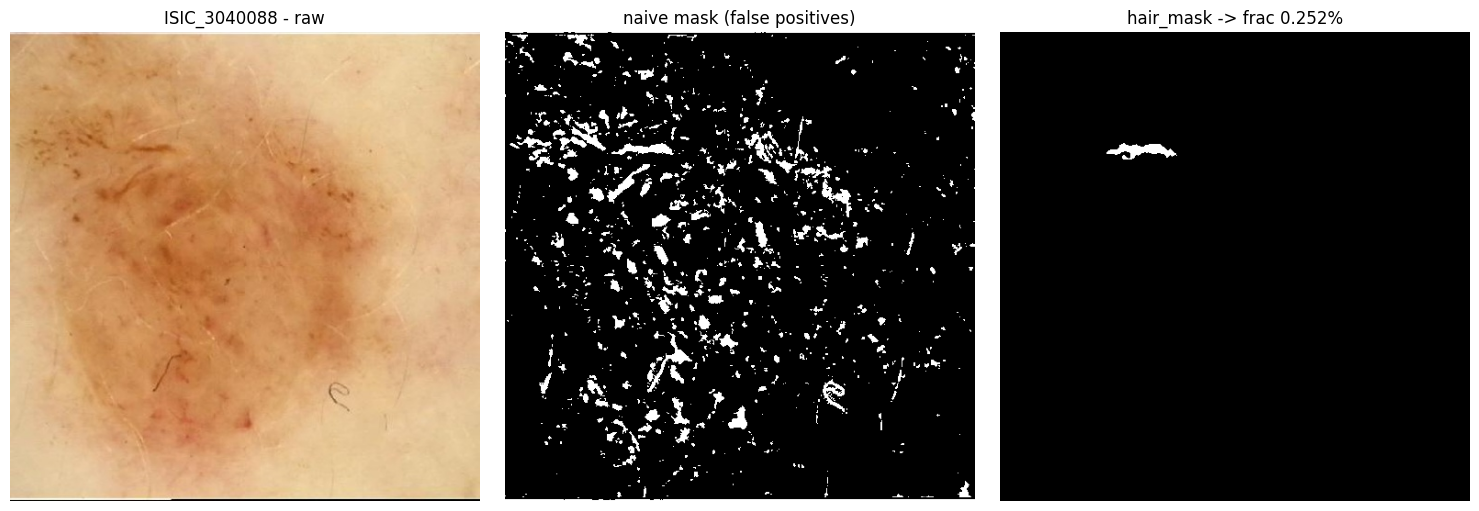

In [16]:
ex_hf = {}
for name in EXAMPLES:
    path = train_df.loc[train_df["image_name"] == name, "image_path"].iloc[0]
    rgb  = to_rgb(path)
    nm, hm = naive_mask(rgb), hair_mask(rgb)
    hf = float((hm > 0).mean()); ex_hf[name] = hf
    print(f"{name}: naive {100 * (nm > 0).mean():6.2f}%   ->   hair_frac {100 * hf:.3f}%")
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(rgb);             ax[0].set_title(f"{name} - raw")
    ax[1].imshow(nm, cmap="gray"); ax[1].set_title("naive mask (false positives)")
    ax[2].imshow(hm, cmap="gray"); ax[2].set_title(f"hair_mask -> frac {100 * hf:.3f}%")
    for a in ax:
        a.axis("off")
    plt.tight_layout(); plt.show()

## 4. Whole pipeline

Every image is DullRazor'd with the shape-filtered mask and written to the output
folder; `hair_frac` is recorded **in the same pass**. No routing here -- outliers
are handled afterwards, from the recorded table (Section 5).

In [17]:
def remove_hair_final(rgb, dilate=0, inpaint_radius=1):
    '''Shape-filtered hair_mask -> (optional dilate) -> Telea inpaint.
    Only masked pixels change. Set dilate=3 if faint hair edges remain.'''
    mask = hair_mask(rgb)
    if dilate:
        mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate, dilate)))
    clean = cv2.inpaint(rgb, mask, inpaint_radius, cv2.INPAINT_TELEA)
    return clean, mask

In [18]:
OUT_TRAIN = BASE + "/train_hair_final"
OUT_TEST  = BASE + "/test_hair_final"
Path(OUT_TRAIN).mkdir(exist_ok=True)
Path(OUT_TEST).mkdir(exist_ok=True)

def run_pipeline(df, out_dir):
    '''DullRazor every image -> out_dir/<name>.jpg (native size, q100);
    record hair_frac in the same pass. Returns df + manifest (one_to_one merge).'''
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    recs = []
    for name, path in tqdm(zip(df["image_name"], df["image_path"]), total=len(df)):
        rec = {"image_name": name, "hair_frac": np.nan, "route": "dullrazor",
               "status": "ok", "out_path": None}
        try:
            rgb = to_rgb(path)
            clean, mask = remove_hair_final(rgb)
            rec["hair_frac"] = float((mask > 0).mean())
            dst = out_dir / f"{name}.jpg"
            cv2.imwrite(str(dst), cv2.cvtColor(clean, cv2.COLOR_RGB2BGR),
                        [int(cv2.IMWRITE_JPEG_QUALITY), 100])
            rec["out_path"] = str(dst)
        except Exception as e:
            rec["status"] = f"error:{type(e).__name__}"
        recs.append(rec)
    out = df.merge(pd.DataFrame(recs), on="image_name", how="left", validate="one_to_one")
    assert len(out) == len(df), "row count changed - correspondence broken"
    return out

In [19]:
train_final = run_pipeline(train_df, OUT_TRAIN)
test_final  = run_pipeline(test_df,  OUT_TEST)

print(train_final["status"].value_counts())
print(test_final["status"].value_counts())
print(train_final["hair_frac"].describe().round(4))

  0%|          | 0/6864 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Outlier handling (post-processing)

`hair_frac` is right-skewed and zero-inflated, so bounds use **Tukey's fences on
`log(hair_frac)`** for the non-zero values (Tukey, 1977), plus exact zeros:

| flag | meaning |
|---|---|
| `raw_zero` | `hair_frac == 0` — no hair detected (DullRazor was a no-op + re-encode) |
| `raw_low`  | `hair_frac < lo_fence` — detection barely above noise / likely filter leakage |
| `raw_high` | `hair_frac > hi_fence` — extreme coverage |

Fences are computed from **train** and applied to both splits. Each flagged image's
saved file is overwritten with a byte-for-byte copy of the raw image and its
`route` is relabelled. `K = 1.5` is the standard Tukey multiplier; `3.0` ("far
out") flags fewer.

In [ ]:
K = 1.5

hf = train_final["hair_frac"].dropna().values
L  = np.log(hf[hf > 0])
q1, q3 = np.percentile(L, [25, 75]); iqr = q3 - q1
LO = float(np.exp(q1 - K * iqr))
HI = float(np.exp(q3 + K * iqr))
print(f"non-zero n={len(L)}   lo_fence={LO:.5f}   hi_fence={HI:.5f}")

def classify(hfv):
    if not np.isfinite(hfv):   return "error"
    if hfv == 0:               return "raw_zero"
    if hfv < LO:               return "raw_low"
    if hfv > HI:               return "raw_high"
    return "dullrazor"

for m in (train_final, test_final):
    m["route"] = m["hair_frac"].apply(classify)

print(train_final["route"].value_counts())

In [ ]:
import shutil

def revert_outliers(m):
    flagged = m[m["route"].str.startswith("raw_") & (m["status"] == "ok")]
    for _, r in tqdm(flagged.iterrows(), total=len(flagged)):
        shutil.copyfile(r["image_path"], r["out_path"])   # overwrite processed .jpg with raw
    return len(flagged)

print("reverted -> raw:  train", revert_outliers(train_final),
      " test", revert_outliers(test_final))

train_final.to_csv(BASE + "/train_hair_final_manifest.csv", index=False)
test_final.to_csv(BASE + "/test_hair_final_manifest.csv",  index=False)

## 6. Outlier summary

In [ ]:
def summary(m, split):
    g = m.groupby("route").agg(n=("image_name", "size"),
                               hf_min=("hair_frac", "min"),
                               hf_max=("hair_frac", "max"))
    g["pct"]   = (100 * g["n"] / len(m)).round(2)
    g["split"] = split
    return g.reset_index()[["split", "route", "n", "pct", "hf_min", "hf_max"]]

report = pd.concat([summary(train_final, "train"), summary(test_final, "test")], ignore_index=True)
print(report.to_string(index=False))

# does reverting fall unevenly across benign / malignant?
for name, m in [("train", train_final), ("test", test_final)]:
    rev = m[m["route"].str.startswith("raw_")]
    tab = pd.DataFrame({"reverted": rev.groupby("target").size(),
                        "total":    m.groupby("target").size()})
    tab["reverted_pct"] = (100 * tab["reverted"] / tab["total"]).round(2)
    print(f"\n{name} reverted-to-raw by target:")
    print(tab.fillna(0).to_string())

In [ ]:
plt.figure(figsize=(12, 4))
plt.hist(train_final["hair_frac"].dropna(), bins=60, color="#4C72B0", edgecolor="white")
plt.axvline(LO, color="green", ls="--", lw=2, label=f"lo_fence = {LO:.4f}")
plt.axvline(HI, color="red",   ls="--", lw=2, label=f"hi_fence = {HI:.4f}")
for v in ex_hf.values():
    plt.axvline(v, color="black", lw=1)
plt.yscale("log"); plt.xlabel("hair_frac"); plt.ylabel("images (log)")
plt.title("train hair_frac with Tukey fences  (black = random_state=3 examples)")
plt.legend(); plt.tight_layout(); plt.show()

### Notes

- Bounds from **train only**, applied to both splits; nothing is dropped -- every
  image is in the output folder, either DullRazor'd or the raw copy.
- Manifest columns: label columns + `hair_frac`, `route`
  (`dullrazor` / `raw_zero` / `raw_low` / `raw_high` / `error`), `status`, `out_path`;
  original row order; `one_to_one`-validated.
- `hair_frac` is recorded for **every** image during processing (Section 4), so
  Section 5 re-runs instantly against a different `K` without touching the images.
- Speed: `!cp -r` the `train`/`test` folders to `/content` and re-point
  `TRAIN_DIR`/`TEST_DIR` before `add_image_path`.